In [1]:
import typing_extensions; print(typing_extensions.__file__); print(hasattr(typing_extensions, 'TypeIs'))

C:\Users\arabe\superSlay\DLSuperSlay\.venv\Lib\site-packages\typing_extensions.py
True


 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


Loaded PyTorch TimesFM, likely because python version is 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

RMSE:       639.57
MAPE:       5.22%
Pearson R²: 0.6405
Directional Accuracy: 56.67%


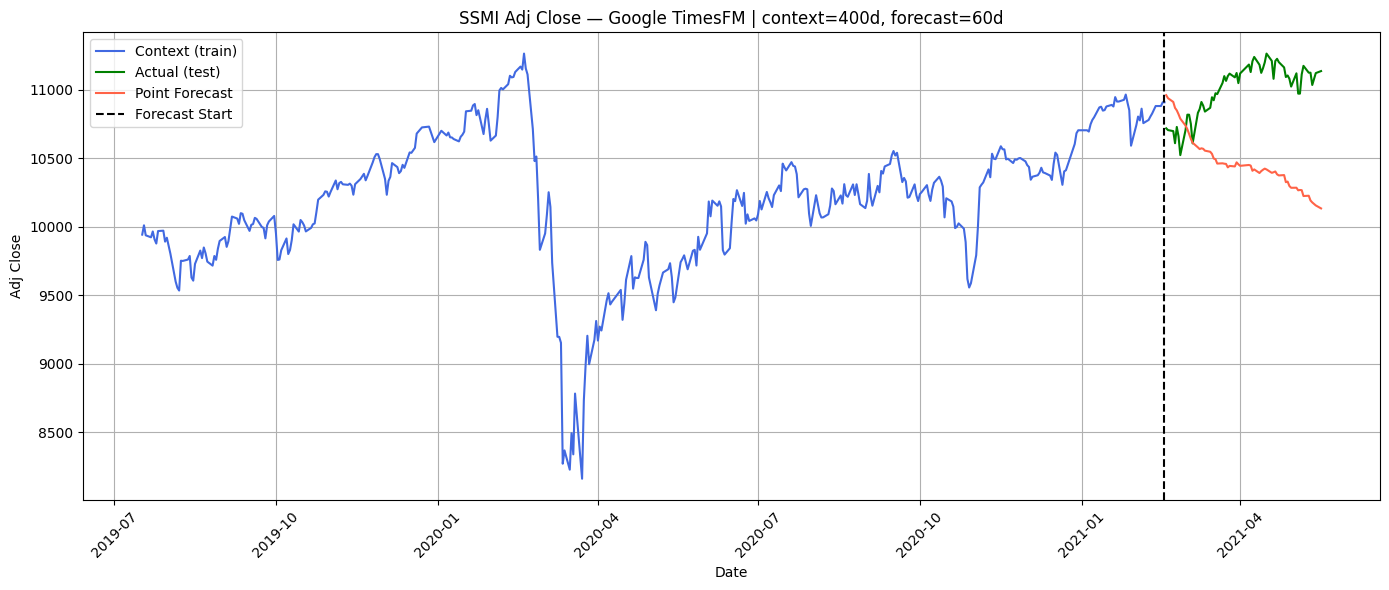

In [2]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

# ========================
# 1) Load SSMI data
# ========================
df = pd.read_csv("../DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Control window size
context_length    = 400
prediction_length = 60

total_window = context_length + prediction_length
df_window = df.tail(total_window).reset_index(drop=True)

y = df_window["Adj Close"].values.astype(float)

y_train = y[:context_length]
y_test  = y[context_length:]

# ========================
# 2) Load Google TimesFM
# ========================
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="cpu",
        per_core_batch_size=32,
        horizon_len=prediction_length,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch",
    ),
)

# ========================
# 3) Forecast
# ========================
point_forecast, experimental_quantile_forecast = tfm.forecast(
    [y_train],
    freq=[0],  # 0 = no specific frequency / daily-like
)

median_forecast = point_forecast[0][:prediction_length]

# ========================
# 4) Metrics
# ========================
rmse = np.sqrt(mean_squared_error(y_test, median_forecast))
mape = mean_absolute_percentage_error(y_test, median_forecast) * 100
pearson_r2 = pearsonr(y_test, median_forecast).statistic ** 2

prev_values = np.concatenate([[y_train[-1]], y_test[:-1]])
pred_prev   = np.concatenate([[y_train[-1]], median_forecast[:-1]])
actual_direction = np.sign(y_test - prev_values)
pred_direction   = np.sign(median_forecast - pred_prev)
directional_accuracy = (actual_direction == pred_direction).mean() * 100

print(f"RMSE:       {rmse:.2f}")
print(f"MAPE:       {mape:.2f}%")
print(f"Pearson R²: {pearson_r2:.4f}")
print(f"Directional Accuracy: {directional_accuracy:.2f}%")

# ========================
# 5) Plot
# ========================
dates      = df_window["Date"].values
test_dates = dates[context_length:context_length + prediction_length]

plt.figure(figsize=(14, 6))
plt.plot(dates[:context_length], y[:context_length], color="royalblue", label="Context (train)")
plt.plot(dates[context_length:], y[context_length:], color="green", label="Actual (test)")
plt.plot(test_dates, median_forecast, color="tomato", label="Point Forecast")
plt.axvline(x=dates[context_length - 1], color="black", linestyle="--", label="Forecast Start")

plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Adj Close")
plt.title(f"SSMI Adj Close — Google TimesFM | context={context_length}d, forecast={prediction_length}d")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Experiments:
#### I will divide the data in segments — each segment will be forecasted, each forecast will give a
- #### RMSE,
- #### MAPE 
- #### R² value.
#### This will then be summarised using a box plot.

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Segment 1/251 — RMSE: 68.46 | MAPE: 3.47% | R²: 0.6042 | Dir Acc: 53.3%


Segment 2/251 — RMSE: 39.64 | MAPE: 2.18% | R²: 0.6142 | Dir Acc: 46.7%


Segment 3/251 — RMSE: 32.26 | MAPE: 0.95% | R²: 0.0008 | Dir Acc: 46.7%


Segment 4/251 — RMSE: 21.14 | MAPE: 1.12% | R²: 0.1779 | Dir Acc: 63.3%


...

Segment 248/251 — RMSE: 379.50 | MAPE: 3.38% | R²: 0.2985 | Dir Acc: 60.0%


Segment 249/251 — RMSE: 275.95 | MAPE: 1.94% | R²: 0.1523 | Dir Acc: 40.0%


Segment 250/251 — RMSE: 448.12 | MAPE: 4.00% | R²: 0.0261 | Dir Acc: 33.3%


Segment 251/251 — RMSE: 434.72 | MAPE: 3.37% | R²: 0.3841 | Dir Acc: 56.7%

--- Median Metrics for Google TimesFM on SSMI ---
Median RMSE:       165.9249
Median MAPE:       2.2538%
Median Pearson R²: 0.3556
Directional Accuracy: 3907/7530 days (51.89%)


C:\Users\arabe\AppData\Local\Temp\ipykernel_39364\2934075701.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)


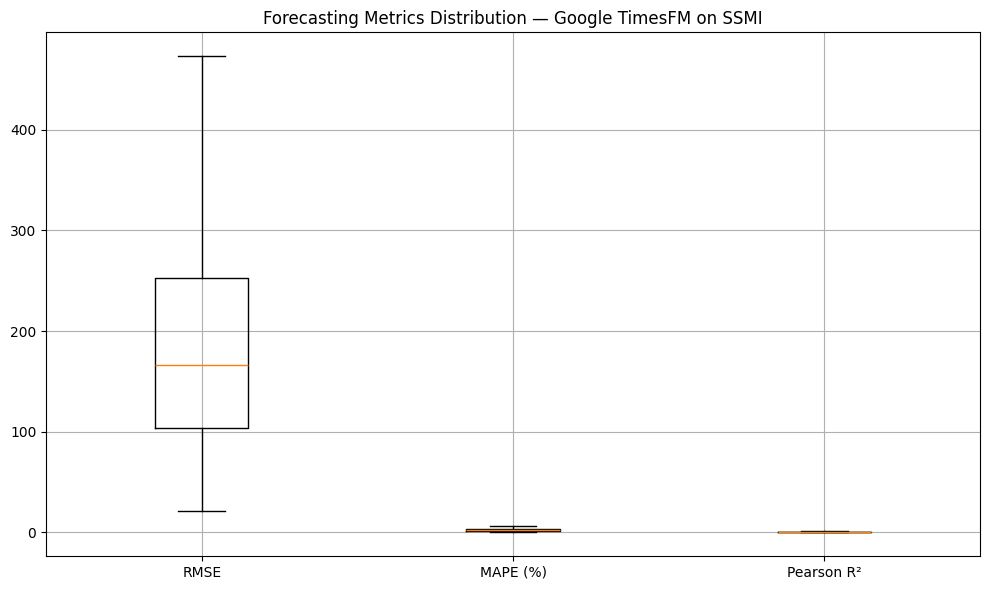

In [3]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
import logging
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='TimesFM_SSMI_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s'
)

def main():
    try:
        # ========================
        # 1) Load SSMI data
        # ========================
        df = pd.read_csv("../DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
        df = df.sort_values("Date").reset_index(drop=True)

        y = df["Adj Close"].values.astype(float)
        total_samples = len(y)
        logging.info(f"Total SSMI samples loaded: {total_samples}")

        # ========================
        # 2) Sliding window config
        # ========================
        context_window   = 120
        forecast_horizon = 30
        step_size        = 30
        num_segments     = (total_samples - context_window) // step_size

        logging.info(f"Segments to evaluate: {num_segments}")

        # ========================
        # 3) Load Google TimesFM
        # ========================
        tfm = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend="cpu",
                per_core_batch_size=32,
                horizon_len=forecast_horizon,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id="google/timesfm-1.0-200m-pytorch",
            ),
        )
        logging.info("Google TimesFM loaded successfully.")

        # ========================
        # 4) Sliding window loop
        # ========================
        rmse_list        = []
        mape_list        = []
        pearson_list     = []
        directional_hits = []

        for segment in range(num_segments):
            start_context = segment * step_size
            end_context   = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            context     = y[start_context:end_context]
            true_values = y[end_context:end_context + forecast_horizon]

            point_forecast, _ = tfm.forecast(
                [context],
                freq=[0],
            )

            median_forecast = point_forecast[0][:forecast_horizon]

            prev_values = np.concatenate([[y[end_context - 1]], true_values[:-1]])
            pred_prev   = np.concatenate([[y[end_context - 1]], median_forecast[:-1]])
            actual_direction = np.sign(true_values - prev_values)
            pred_direction   = np.sign(median_forecast - pred_prev)
            hits = (actual_direction == pred_direction).astype(int)
            segment_dir_acc = hits.mean() * 100
            directional_hits.extend(hits.tolist())

            rmse       = np.sqrt(mean_squared_error(true_values, median_forecast))
            mape       = mean_absolute_percentage_error(true_values, median_forecast) * 100
            pearson_r2 = pearsonr(true_values, median_forecast).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(pearson_r2)

            logging.info(f"Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, Pearson R²={pearson_r2:.4f}, DirAcc={segment_dir_acc:.1f}%")
            print(f"Segment {segment+1}/{num_segments} — RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R²: {pearson_r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%")

        # ========================
        # 5) Save results
        # ========================
        np.savez_compressed("TimesFM_SSMI_Metrics.npz",
                            rmse=np.array(rmse_list),
                            mape=np.array(mape_list),
                            pearson_coefficients=np.array(pearson_list),
                            directional_hits=np.array(directional_hits),
                            context_window=context_window,
                            forecast_horizon=forecast_horizon,
                            num_segments=num_segments)
        logging.info("Results saved to TimesFM_SSMI_Metrics.npz")

        # ========================
        # 6) Summary metrics
        # ========================
        total_days  = len(directional_hits)
        total_hits  = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100

        print("\n--- Median Metrics for Google TimesFM on SSMI ---")
        print(f"Median RMSE:       {np.median(rmse_list):.4f}")
        print(f"Median MAPE:       {np.median(mape_list):.4f}%")
        print(f"Median Pearson R²: {np.median(pearson_list):.4f}")
        print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

        # ========================
        # 7) Box plots
        # ========================
        metrics = {
            "RMSE":       rmse_list,
            "MAPE (%)":   mape_list,
            "Pearson R²": pearson_list,
        }

        plt.figure(figsize=(10, 6))
        plt.boxplot(metrics.values(), labels=metrics.keys(), showfliers=False)
        plt.title("Forecasting Metrics Distribution — Google TimesFM on SSMI")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        logging.error("An error occurred.", exc_info=True)
        print("An error occurred. Check TimesFM_SSMI_Metrics.log for details.")
        try:
            np.savez_compressed("partial_TimesFM_SSMI_Metrics.npz",
                                rmse=np.array(rmse_list) if 'rmse_list' in locals() else None,
                                mape=np.array(mape_list) if 'mape_list' in locals() else None,
                                pearson_coefficients=np.array(pearson_list) if 'pearson_list' in locals() else None,
                                directional_hits=np.array(directional_hits) if 'directional_hits' in locals() else None)
        except Exception as save_exception:
            logging.error("Failed to save partial results.", exc_info=True)
    finally:
        logging.info("Forecasting run completed.")

if __name__ == '__main__':
    main()

In [4]:
import numpy as np

data = np.load("TimesFM_SSMI_Metrics.npz")

total_days = len(data['directional_hits'])
total_hits = int(data['directional_hits'].sum())
dir_acc_pct = (total_hits / total_days) * 100

print("--- Median Metrics for Google TimesFM on SSMI ---")
print(f"Median RMSE:       {np.median(data['rmse']):.4f}")
print(f"Median MAPE:       {np.median(data['mape']):.4f}%")
print(f"Median Pearson R²: {np.median(data['pearson_coefficients']):.4f}")
print(f"Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)")

--- Median Metrics for Google TimesFM on SSMI ---
Median RMSE:       165.9249
Median MAPE:       2.2538%
Median Pearson R²: 0.3556
Directional Accuracy: 3907/7530 days (51.89%)
